# Huấn luyện mô hình dự đoán tuổi Abalone

Sổ tay này thực hiện bước huấn luyện mô hình cho bài toán hồi quy dự đoán `Rings` (ước lượng tuổi gần đúng theo công thức `Age = Rings + 1.5`). Nội dung bám theo quy trình đã xây dựng ở notebook `02_tien_xu_ly_du_lieu.ipynb`.

## 1. Mục tiêu huấn luyện

- So sánh hiệu năng của nhiều mô hình hồi quy trên các chiến lược tiền xử lý khác nhau.
- Đánh giá theo các chỉ số `MAE`, `RMSE`, `R2`.
- Chọn mô hình tốt nhất theo `RMSE` trên tập kiểm tra.
- Lưu mô hình và kết quả để phục vụ notebook đánh giá (`04_danh_gia_mo_hinh.ipynb`).

## 2. Import thư viện và cấu hình

In [ ]:
import json
import pickle
import warnings
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 100)

## 3. Thiết lập đường dẫn và nạp dữ liệu đầu vào

Dữ liệu sử dụng ở bước này được lấy từ kết quả notebook 02, gồm nhiều chiến lược tiền xử lý để so sánh công bằng giữa các mô hình.

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
INTERIM_DATA_PATH = PROJECT_ROOT / "data" / "interim"
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed"
OUTPUT_MODELS_PATH = PROJECT_ROOT / "outputs" / "models"
OUTPUT_METRICS_PATH = PROJECT_ROOT / "outputs" / "metrics"
OUTPUT_FIGURES_PATH = PROJECT_ROOT / "outputs" / "figures"

OUTPUT_MODELS_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_METRICS_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES_PATH.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"INTERIM_DATA_PATH tồn tại: {INTERIM_DATA_PATH.exists()}")
print(f"PROCESSED_DATA_PATH tồn tại: {PROCESSED_DATA_PATH.exists()}")

PROJECT_ROOT: C:\Users\Admin\Documents\GitHub\TNTT_Repo_Abalone6\AbaloneAge
INTERIM_DATA_PATH tồn tại: True
PROCESSED_DATA_PATH tồn tại: True


In [3]:
def load_pickle(path: Path):
    with open(path, "rb") as f:
        return pickle.load(f)

# Các dataset từ notebook 02
datasets = {
    "baseline_standard": load_pickle(INTERIM_DATA_PATH / "baseline_scaled.pkl")["standard"],
    "baseline_robust": load_pickle(INTERIM_DATA_PATH / "baseline_scaled.pkl")["robust"],
    "iqr_standard": load_pickle(INTERIM_DATA_PATH / "iqr_filtered_scaled.pkl")["standard"],
    "log_standard": load_pickle(INTERIM_DATA_PATH / "log_transformed_scaled.pkl")["standard"],
    "feature_engineering_standard": load_pickle(PROCESSED_DATA_PATH / "baseline_with_features_scaled.pkl"),
}

targets = {
    "baseline_standard": {
        "y_train": load_pickle(INTERIM_DATA_PATH / "baseline_scaled.pkl")["y_train"],
        "y_test": load_pickle(INTERIM_DATA_PATH / "baseline_scaled.pkl")["y_test"],
    },
    "baseline_robust": {
        "y_train": load_pickle(INTERIM_DATA_PATH / "baseline_scaled.pkl")["y_train"],
        "y_test": load_pickle(INTERIM_DATA_PATH / "baseline_scaled.pkl")["y_test"],
    },
    "iqr_standard": {
        "y_train": load_pickle(INTERIM_DATA_PATH / "iqr_filtered_scaled.pkl")["y_train"],
        "y_test": load_pickle(INTERIM_DATA_PATH / "iqr_filtered_scaled.pkl")["y_test"],
    },
    "log_standard": {
        "y_train": load_pickle(INTERIM_DATA_PATH / "log_transformed_scaled.pkl")["y_train"],
        "y_test": load_pickle(INTERIM_DATA_PATH / "log_transformed_scaled.pkl")["y_test"],
    },
    "feature_engineering_standard": {
        "y_train": datasets["feature_engineering_standard"]["y_train"],
        "y_test": datasets["feature_engineering_standard"]["y_test"],
    },
}

for name, data in datasets.items():
    x_train = data["X_train"]
    x_test = data["X_test"]
    print(f"{name:30s} | X_train={x_train.shape} | X_test={x_test.shape}")

baseline_standard              | X_train=(2923, 10) | X_test=(1254, 10)
baseline_robust                | X_train=(2923, 10) | X_test=(1254, 10)
iqr_standard                   | X_train=(2809, 10) | X_test=(1204, 10)
log_standard                   | X_train=(2923, 14) | X_test=(1254, 14)
feature_engineering_standard   | X_train=(2923, 15) | X_test=(1254, 15)


## 4. Định nghĩa mô hình và hàm đánh giá

Ta sử dụng cả mô hình tuyến tính lẫn mô hình cây để có góc nhìn cân bằng giữa khả năng diễn giải và hiệu năng dự đoán.

In [4]:
RANDOM_STATE = 42
CV_SPLITS = 5

model_candidates = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Lasso": Lasso(alpha=0.001, random_state=RANDOM_STATE),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "GradientBoosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}


def evaluate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred),
    }


def train_and_evaluate(model, x_train, y_train, x_test, y_test):
    model.fit(x_train, y_train)

    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    train_metrics = evaluate_metrics(y_train, y_train_pred)
    test_metrics = evaluate_metrics(y_test, y_test_pred)

    kfold = KFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    cv_neg_mae = cross_val_score(
        model,
        x_train,
        y_train,
        scoring="neg_mean_absolute_error",
        cv=kfold,
        n_jobs=-1,
    )

    return {
        "model": model,
        "train_metrics": train_metrics,
        "test_metrics": test_metrics,
        "cv_mae_mean": -cv_neg_mae.mean(),
        "cv_mae_std": cv_neg_mae.std(),
        "y_test_pred": y_test_pred,
    }

## 5. Huấn luyện và đánh giá trên từng chiến lược tiền xử lý

In [ ]:
experiment_results = []
trained_artifacts = {}

for dataset_name, data in datasets.items():
    x_train = data["X_train"]
    x_test = data["X_test"]
    y_train = targets[dataset_name]["y_train"]
    y_test = targets[dataset_name]["y_test"]

    for model_name, base_model in model_candidates.items():
        # Tạo bản sao mô hình mới để tránh ghi đè trạng thái đã fit ở lần lặp trước
        model = clone(base_model)
        result = train_and_evaluate(model, x_train, y_train, x_test, y_test)

        key = f"{dataset_name}__{model_name}"
        trained_artifacts[key] = {
            "dataset_name": dataset_name,
            "model_name": model_name,
            "model": result["model"],
            "x_test": x_test,
            "y_test": y_test,
            "y_test_pred": result["y_test_pred"],
        }

        experiment_results.append(
            {
                "dataset": dataset_name,
                "model": model_name,
                "train_mae": result["train_metrics"]["MAE"],
                "train_rmse": result["train_metrics"]["RMSE"],
                "train_r2": result["train_metrics"]["R2"],
                "test_mae": result["test_metrics"]["MAE"],
                "test_rmse": result["test_metrics"]["RMSE"],
                "test_r2": result["test_metrics"]["R2"],
                "cv_mae_mean": result["cv_mae_mean"],
                "cv_mae_std": result["cv_mae_std"],
            }
        )

results_df = pd.DataFrame(experiment_results)
results_df = results_df.sort_values(by=["test_rmse", "test_mae"], ascending=True).reset_index(drop=True)
display(results_df.head(15))

,dataset,model,train_mae,train_rmse,train_r2,test_mae,test_rmse,test_r2,cv_mae_mean,cv_mae_std
0,iqr_standard,RandomForest,0.698582,1.049831,0.885912,1.516249,2.107555,0.548547,1.550210,0.033187
1,feature_engineering_standard,GradientBoosting,1.294290,1.787156,0.695427,1.499678,2.111128,0.561097,1.493650,0.019045
2,iqr_standard,LinearRegression,1.571656,2.171595,0.511843,1.541329,2.128984,0.539320,1.580343,0.046459
3,iqr_standard,Lasso,1.571624,2.171668,0.511810,1.540995,2.129046,0.539293,1.580259,0.046046
4,iqr_standard,Ridge,1.571607,2.171681,0.511804,1.541551,2.129556,0.539072,1.580219,0.046347
5,feature_engineering_standard,RandomForest,0.658820,0.968166,0.910615,1.523888,2.138539,0.549626,1.535931,0.022423
6,log_standard,Ridge,1.532854,2.116403,0.572867,1.544257,2.165876,0.538038,1.553056,0.015684
7,log_standard,Lasso,1.537481,2.122138,0.570549,1.549024,2.169911,0.536315,1.556411,0.015811
8,baseline_standard,RandomForest,0.695058,1.039481,0.896962,1.537912,2.176923,0.533314,1.552512,0.046634
9,baseline_robust,RandomForest,0.695546,1.040194,0.896820,1.537761,2.177126,0.533227,1.553079,0.046234


## 6. Phân tích kết quả và chọn cấu hình tốt nhất

In [6]:
best_row = results_df.iloc[0]
best_key = f"{best_row['dataset']}__{best_row['model']}"
best_artifact = trained_artifacts[best_key]

print("=== CẤU HÌNH TỐT NHẤT ===")
print(f"Chiến lược dữ liệu: {best_row['dataset']}")
print(f"Mô hình: {best_row['model']}")
print(f"Test MAE: {best_row['test_mae']:.4f}")
print(f"Test RMSE: {best_row['test_rmse']:.4f}")
print(f"Test R2: {best_row['test_r2']:.4f}")
print(f"CV MAE (trung bình +- độ lệch chuẩn): {best_row['cv_mae_mean']:.4f} +- {best_row['cv_mae_std']:.4f}")

# Top 10 theo RMSE
print("\nTop 10 cấu hình theo Test RMSE:")
display(results_df.head(10))

=== CẤU HÌNH TỐT NHẤT ===
Chiến lược dữ liệu: iqr_standard
Mô hình: RandomForest
Test MAE: 1.5162
Test RMSE: 2.1076
Test R2: 0.5485
CV MAE (trung bình +- độ lệch chuẩn): 1.5502 +- 0.0332

Top 10 cấu hình theo Test RMSE:


,dataset,model,train_mae,train_rmse,train_r2,test_mae,test_rmse,test_r2,cv_mae_mean,cv_mae_std
0,iqr_standard,RandomForest,0.698582,1.049831,0.885912,1.516249,2.107555,0.548547,1.550210,0.033187
1,feature_engineering_standard,GradientBoosting,1.294290,1.787156,0.695427,1.499678,2.111128,0.561097,1.493650,0.019045
2,iqr_standard,LinearRegression,1.571656,2.171595,0.511843,1.541329,2.128984,0.539320,1.580343,0.046459
3,iqr_standard,Lasso,1.571624,2.171668,0.511810,1.540995,2.129046,0.539293,1.580259,0.046046
4,iqr_standard,Ridge,1.571607,2.171681,0.511804,1.541551,2.129556,0.539072,1.580219,0.046347
5,feature_engineering_standard,RandomForest,0.658820,0.968166,0.910615,1.523888,2.138539,0.549626,1.535931,0.022423
6,log_standard,Ridge,1.532854,2.116403,0.572867,1.544257,2.165876,0.538038,1.553056,0.015684
7,log_standard,Lasso,1.537481,2.122138,0.570549,1.549024,2.169911,0.536315,1.556411,0.015811
8,baseline_standard,RandomForest,0.695058,1.039481,0.896962,1.537912,2.176923,0.533314,1.552512,0.046634
9,baseline_robust,RandomForest,0.695546,1.040194,0.896820,1.537761,2.177126,0.533227,1.553079,0.046234


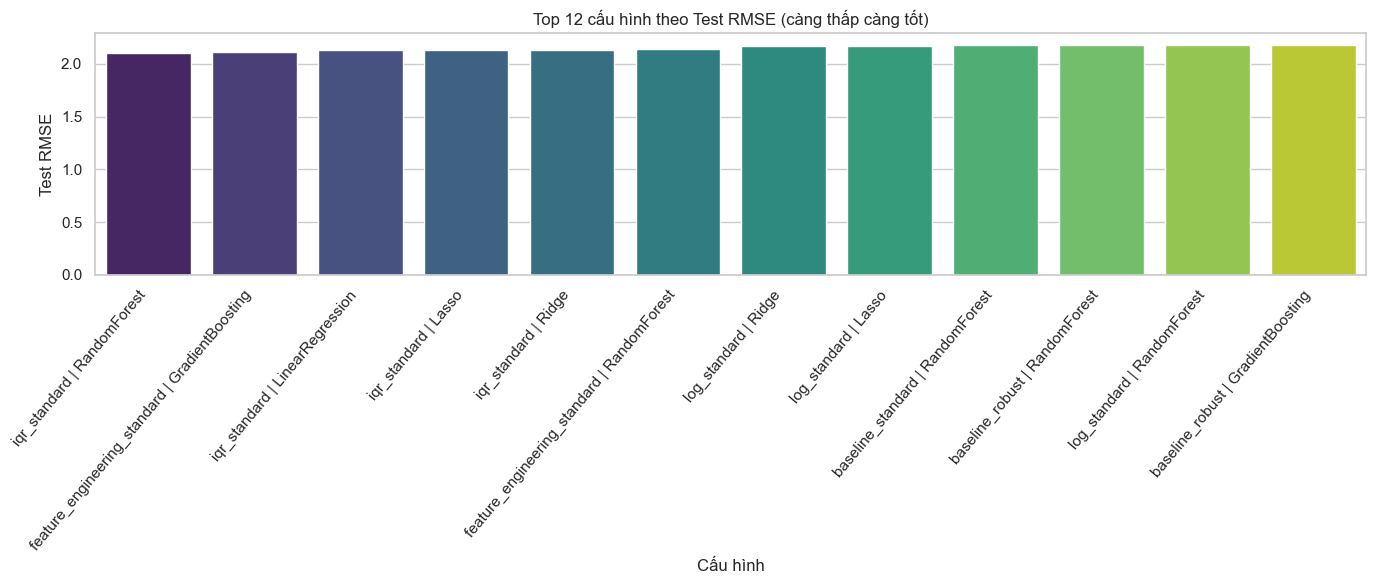

In [7]:
# Trực quan hóa so sánh RMSE theo mô hình và chiến lược
plot_df = results_df.copy()
plot_df["config"] = plot_df["dataset"] + " | " + plot_df["model"]

plt.figure(figsize=(14, 6))
sns.barplot(data=plot_df.head(12), x="config", y="test_rmse", palette="viridis")
plt.xticks(rotation=50, ha="right")
plt.title("Top 12 cấu hình theo Test RMSE (càng thấp càng tốt)")
plt.ylabel("Test RMSE")
plt.xlabel("Cấu hình")
plt.tight_layout()
plt.show()

## 7. Kiểm tra lỗi dự đoán của mô hình tốt nhất

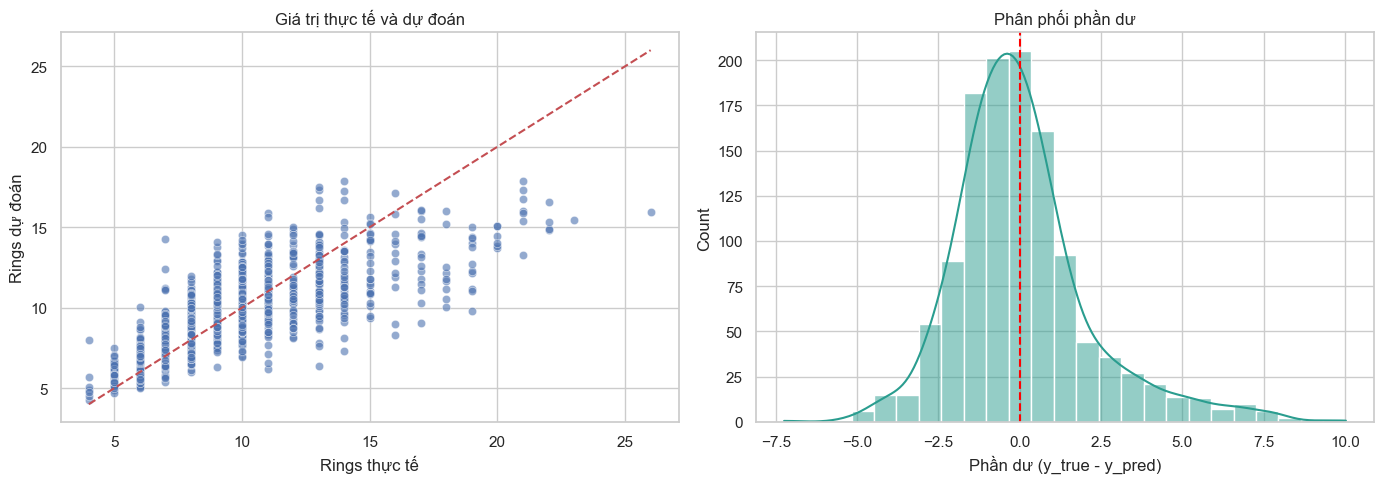

In [8]:
y_true = best_artifact["y_test"]
y_pred = best_artifact["y_test_pred"]
residuals = y_true - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=y_true, y=y_pred, ax=axes[0], alpha=0.6)
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1.5)
axes[0].set_title("Giá trị thực tế và dự đoán")
axes[0].set_xlabel("Rings thực tế")
axes[0].set_ylabel("Rings dự đoán")

sns.histplot(residuals, kde=True, bins=25, ax=axes[1], color="#2a9d8f")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title("Phân phối phần dư")
axes[1].set_xlabel("Phần dư (y_true - y_pred)")

plt.tight_layout()
plt.show()

In [ ]:
best_model = best_artifact["model"]
feature_names = best_artifact["x_test"].columns.tolist()

if hasattr(best_model, "feature_importances_"):
    importances = np.asarray(best_model.feature_importances_).ravel()

    if len(importances) != len(feature_names):
        n = min(len(importances), len(feature_names))
        print(
            f"Cảnh báo: số đặc trưng ({len(feature_names)}) và số độ quan trọng ({len(importances)}) không khớp. "
            f"Sẽ dùng {n} phần tử đầu tiên để hiển thị."
        )
        feature_names = feature_names[:n]
        importances = importances[:n]

    importance_df = pd.DataFrame(
        {
            "feature": feature_names,
            "importance": importances,
        }
    ).sort_values("importance", ascending=False)

    print("Top 15 đặc trưng quan trọng nhất:")
    display(importance_df.head(15))

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df.head(15), x="importance", y="feature", palette="mako")
    plt.title("Top 15 độ quan trọng của đặc trưng")
    plt.xlabel("Mức độ quan trọng")
    plt.ylabel("Đặc trưng")
    plt.tight_layout()
    plt.show()
elif hasattr(best_model, "coef_"):
    coefficients = np.asarray(best_model.coef_).ravel()

    if len(coefficients) != len(feature_names):
        n = min(len(coefficients), len(feature_names))
        print(
            f"Cảnh báo: số đặc trưng ({len(feature_names)}) và số hệ số ({len(coefficients)}) không khớp. "
            f"Sẽ dùng {n} phần tử đầu tiên để hiển thị."
        )
        feature_names = feature_names[:n]
        coefficients = coefficients[:n]

    coef_df = pd.DataFrame(
        {
            "feature": feature_names,
            "coefficient": coefficients,
        }
    )
    coef_df["abs_coef"] = coef_df["coefficient"].abs()
    coef_df = coef_df.sort_values("abs_coef", ascending=False)

    print("Top 15 hệ số có độ lớn cao nhất:")
    display(coef_df.head(15))
else:
    print("Mô hình không hỗ trợ truy xuất độ quan trọng hoặc hệ số trực tiếp.")

ValueError: All arrays must be of the same length

## 8. Lưu mô hình và báo cáo kết quả

In [ ]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

model_path = OUTPUT_MODELS_PATH / "best_regression_model.pkl"
results_path = OUTPUT_METRICS_PATH / "model_comparison_results.csv"
summary_path = OUTPUT_METRICS_PATH / "best_model_summary.json"
figure_path = OUTPUT_FIGURES_PATH / f"best_model_residuals_{timestamp}.png"

# Lưu mô hình tốt nhất
with open(model_path, "wb") as f:
    pickle.dump(best_model, f)

# Lưu bảng so sánh đầy đủ
results_df.to_csv(results_path, index=False)

# Lưu tóm tắt mô hình tốt nhất
best_summary = {
    "timestamp": timestamp,
    "best_dataset": str(best_row["dataset"]),
    "best_model": str(best_row["model"]),
    "test_mae": float(best_row["test_mae"]),
    "test_rmse": float(best_row["test_rmse"]),
    "test_r2": float(best_row["test_r2"]),
    "cv_mae_mean": float(best_row["cv_mae_mean"]),
    "cv_mae_std": float(best_row["cv_mae_std"]),
}

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(best_summary, f, ensure_ascii=False, indent=2)

plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_true, y=y_pred, alpha=0.6)
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], "r--", linewidth=1.5)
plt.title("Mô hình tốt nhất: Giá trị thực tế và dự đoán")
plt.xlabel("Rings thực tế")
plt.ylabel("Rings dự đoán")
plt.tight_layout()
plt.savefig(figure_path, dpi=160)
plt.show()

print("Đã lưu các tệp kết quả:")
print(f"- Mô hình: {model_path}")
print(f"- Bảng kết quả CSV: {results_path}")
print(f"- Tóm tắt JSON: {summary_path}")
print(f"- Hình minh họa: {figure_path}")

## 9. Kết luận

- Notebook đã huấn luyện và so sánh nhiều mô hình trên nhiều chiến lược tiền xử lý.
- Cấu hình tốt nhất được lựa chọn theo tiêu chí `Test RMSE` và đã được lưu đầy đủ vào thư mục `outputs/`.
- Kết quả từ bước này là đầu vào trực tiếp cho notebook `04_danh_gia_mo_hinh.ipynb` để đánh giá độ tin cậy và khả năng tổng quát hóa chi tiết hơn.